In [1]:
import polars as pl
import polars.selectors as cs
import numpy as np

In [2]:
sushi_path = "./data/sushi3.idata"
sushi_df = pl.read_csv(
    sushi_path, separator="\t", has_header=False, 
    new_columns=[
        "id", "name", "style", "major_group",
        "minor_group", "oiliness", "eaten_frequency",
        "price", "sold_frequency"
    ]
)

sushi_df.head()

id,name,style,major_group,minor_group,oiliness,eaten_frequency,price,sold_frequency
i64,str,i64,i64,i64,f64,f64,f64,f64
0,"""ebi""",1,0,6,2.728978,2.138422,1.83842,0.84
1,"""anago""",1,0,3,0.926384,1.990228,1.992459,0.88
2,"""maguro""",1,0,1,1.769559,2.348506,1.874725,0.88
3,"""ika""",1,0,5,2.688401,2.04324,1.515152,0.92
4,"""uni""",1,0,8,0.813043,1.643478,3.287282,0.88


In [3]:
def prep_sushi(df, nominal_fields, numerical_fields, drop_fields, num_rows, id_field = "id"):
    df = df.limit(
        num_rows
    ).sort(
        id_field
    )
    arr = df.drop(
        drop_fields
    ).with_columns(
        (pl.col(numerical_fields) - pl.col(numerical_fields).min()) / (pl.col(numerical_fields).max() - pl.col(numerical_fields).min())
    ).with_columns(
        df[nominal_fields].to_dummies(drop_first=True)
    ).to_numpy()

    inds = (df[id_field].sort() + 1).to_list()

    return arr, inds

nominal_fields = ["minor_group"]
numerical_fields = ["oiliness", "eaten_frequency", "price", "sold_frequency"]
drop_fields = ["id", "name", "major_group"] + nominal_fields

sushi_arr, sushi_inds = prep_sushi(sushi_df, nominal_fields, numerical_fields, drop_fields, 10)

sushi_arr

array([[1.        , 0.85828263, 0.70201946, 0.2334073 , 0.5       ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        ],
       [1.        , 0.14765004, 0.49182399, 0.2780176 , 0.75      ,
        0.        , 1.        , 0.        , 0.        , 0.        ,
        0.        ],
       [1.        , 0.48005296, 1.        , 0.24392127, 0.75      ,
        1.        , 0.        , 0.        , 0.        , 0.        ,
        0.        ],
       [1.        , 0.84228598, 0.56701463, 0.13978737, 1.        ,
        0.        , 0.        , 1.        , 0.        , 0.        ,
        0.        ],
       [1.        , 0.1029679 , 0.        , 0.65300401, 0.75      ,
        0.        , 0.        , 0.        , 0.        , 1.        ,
        0.        ],
       [1.        , 1.        , 0.10477308, 0.10190094, 0.        ,
        0.        , 0.        , 1.        , 0.        , 0.        ,
        0.        ],
       [1.        , 0.28109149, 0.47655331, 0.48158165, 0.

In [4]:
from mallows import TopKMallows, DiverseTopKMallows

In [5]:
algo_beta = 0.5
p_penalty = 0.321
algo_k = 2
universe = [0] + sushi_inds[:5]

algo_1 = TopKMallows(center=[1, 4, 3, 2, 5], k=algo_k, beta=algo_beta, p=p_penalty)

algo_1.profile_sampling_probs(universe)

defaultdict(<function mallows.TopKMallows.profile_sampling_probs.<locals>.<lambda>()>,
            {frozenset({1, 2}): np.float64(0.1413860199253529),
             frozenset({1, 3}): np.float64(0.1413860199253529),
             frozenset({1, 4}): np.float64(0.23310613843056144),
             frozenset({1, 5}): np.float64(0.1413860199253529),
             frozenset({2, 3}): np.float64(0.028490311324992083),
             frozenset({2, 4}): np.float64(0.08575495593946783),
             frozenset({2, 5}): np.float64(0.028490311324992083),
             frozenset({3, 4}): np.float64(0.08575495593946783),
             frozenset({3, 5}): np.float64(0.028490311324992083),
             frozenset({4, 5}): np.float64(0.08575495593946783)})

In [6]:
algo_alpha = 0.0
algo_sigma = 1.5

algo_2 = DiverseTopKMallows(center=[1, 4, 3, 2, 5], k=algo_k, beta=algo_beta, p=p_penalty, embeddings=sushi_arr, alpha=algo_alpha, sigma=algo_sigma)

algo_2.profile_sampling_probs(universe)

defaultdict(<function mallows.DiverseTopKMallows.profile_sampling_probs.<locals>.<lambda>()>,
            {frozenset({1, 2}): np.float64(0.1413860199253529),
             frozenset({1, 3}): np.float64(0.1413860199253529),
             frozenset({1, 4}): np.float64(0.23310613843056144),
             frozenset({1, 5}): np.float64(0.1413860199253529),
             frozenset({2, 3}): np.float64(0.028490311324992083),
             frozenset({2, 4}): np.float64(0.08575495593946783),
             frozenset({2, 5}): np.float64(0.028490311324992083),
             frozenset({3, 4}): np.float64(0.08575495593946783),
             frozenset({3, 5}): np.float64(0.028490311324992083),
             frozenset({4, 5}): np.float64(0.08575495593946783)})

In [7]:
algo_alpha = 0.85
algo_sigma = 1.5

algo_2 = DiverseTopKMallows(center=[1, 4, 3, 2, 5], k=algo_k, beta=algo_beta, p=p_penalty, embeddings=sushi_arr, alpha=algo_alpha, sigma=algo_sigma)

algo_2.profile_sampling_probs(universe)

defaultdict(<function mallows.DiverseTopKMallows.profile_sampling_probs.<locals>.<lambda>()>,
            {frozenset({1, 2}): np.float64(0.140187331753248),
             frozenset({1, 3}): np.float64(0.1354288499471916),
             frozenset({1, 4}): np.float64(0.18405451539126566),
             frozenset({1, 5}): np.float64(0.14841393551891136),
             frozenset({2, 3}): np.float64(0.03368487879292778),
             frozenset({2, 4}): np.float64(0.09645387127709637),
             frozenset({2, 5}): np.float64(0.033690407567628235),
             frozenset({3, 4}): np.float64(0.09583663929099948),
             frozenset({3, 5}): np.float64(0.033976598384764106),
             frozenset({4, 5}): np.float64(0.09827297207596748)})

In [8]:
algo_alpha = 0.75
algo_sigma = 2.0

algo_2 = DiverseTopKMallows(center=[1, 4, 3, 2, 5], k=algo_k, beta=algo_beta, p=p_penalty, embeddings=sushi_arr, alpha=algo_alpha, sigma=algo_sigma)

algo_2.profile_sampling_probs(universe)

defaultdict(<function mallows.DiverseTopKMallows.profile_sampling_probs.<locals>.<lambda>()>,
            {frozenset({1, 2}): np.float64(0.14013440734199134),
             frozenset({1, 3}): np.float64(0.13733133630848632),
             frozenset({1, 4}): np.float64(0.18690531381082487),
             frozenset({1, 5}): np.float64(0.14546795188901032),
             frozenset({2, 3}): np.float64(0.03396748313567508),
             frozenset({2, 4}): np.float64(0.09568752390769833),
             frozenset({2, 5}): np.float64(0.03397138253834464),
             frozenset({3, 4}): np.float64(0.09524340567780817),
             frozenset({3, 5}): np.float64(0.03419147901644277),
             frozenset({4, 5}): np.float64(0.09709971637371839)})

## Using User Data

In [9]:
sushi_path = "./data/sushi3a.5000.10.order"
pref_arr = pl.read_csv(
    sushi_path, separator=" ", has_header=False, skip_lines=1
).select(
    cs.exclude(cs.by_index([0, 1]))
).to_numpy()

pref_list = pref_arr.tolist()
pref_arr

array([[5, 0, 3, ..., 1, 7, 2],
       [0, 9, 6, ..., 1, 5, 4],
       [7, 0, 2, ..., 1, 9, 6],
       ...,
       [7, 2, 4, ..., 0, 8, 9],
       [7, 2, 3, ..., 9, 6, 4],
       [0, 5, 3, ..., 9, 8, 1]], shape=(5000, 10))

In [10]:
items = [1, 2, 3, 4, 5]

for i in range(len(items)):
    for j in range(i+1, len(items)):
        print(items[i], items[j])

1 2
1 3
1 4
1 5
2 3
2 4
2 5
3 4
3 5
4 5


In [11]:
from joblib import Parallel, delayed
from collections import defaultdict

def process_thing(i, j):
    res = ["yo", "gurt"] if i % 2 == 0 else ["gurt", "yo"]
    return (i * j, res)

items = [1, 2, 3, 4, 5]
ind_pairs_test = []

for i in range(len(items)):
    for j in range(i+1, len(items)):
        ind_pairs_test.append((i, j))

dict_test = defaultdict(list)
res = Parallel(n_jobs=2, verbose=10)(
    delayed(process_thing)(*pair) for pair in ind_pairs_test
)

for key, val in res:
    dict_test[key].append(val)

dict_test

[Parallel(n_jobs=2)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done   1 tasks      | elapsed:    0.2s
[Parallel(n_jobs=2)]: Batch computation too fast (0.15842628479003906s.) Setting batch_size=2.
[Parallel(n_jobs=2)]: Done   4 tasks      | elapsed:    0.2s
[Parallel(n_jobs=2)]: Batch computation too fast (0.0025894641876220703s.) Setting batch_size=4.
[Parallel(n_jobs=2)]: Done  10 out of  10 | elapsed:    0.2s finished


defaultdict(list,
            {0: [['yo', 'gurt'],
              ['yo', 'gurt'],
              ['yo', 'gurt'],
              ['yo', 'gurt']],
             2: [['gurt', 'yo']],
             3: [['gurt', 'yo']],
             4: [['gurt', 'yo']],
             6: [['yo', 'gurt']],
             8: [['yo', 'gurt']],
             12: [['gurt', 'yo']]})

In [12]:
dict(res)

{0: ['yo', 'gurt'],
 2: ['gurt', 'yo'],
 3: ['gurt', 'yo'],
 4: ['gurt', 'yo'],
 6: ['yo', 'gurt'],
 8: ['yo', 'gurt'],
 12: ['gurt', 'yo']}

In [13]:
import pickle
from collections import defaultdict
from joblib import Parallel, delayed

#"""
def process_pair(i, j):
    rank_i = [ind + 1 for ind in pref_list[i]]
    rank_j = [ind + 1 for ind in pref_list[j]]
    dist = TopKMallows.kendall_distance(rank_i, rank_j, algo_k, p_penalty)
    return (dist, (rank_i, rank_j))

ind_pairs = []

for i in range(len(pref_list)):
    for j in range(i+1, len(pref_list)):
        ind_pairs.append((i, j))

p_penalty = 0.321
algo_k = 10

res = Parallel(n_jobs=-2, verbose=10)(
    delayed(process_pair)(*pair) for pair in ind_pairs
)

furthest_ranks = defaultdict(list)
for key, val in res:
    furthest_ranks[key].append(val)
#"""

#"""
with open("data/pref_distances.pickle", 'wb') as file:
    pickle.dump(furthest_ranks, file)
#"""

"""
with open("data/pref_distances.pickle", 'rb') as file:
    furthest_ranks = pickle.load(file)
#"""

furthest_ranks

[Parallel(n_jobs=-2)]: Using backend LokyBackend with 11 concurrent workers.
[Parallel(n_jobs=-2)]: Batch computation too fast (0.15805530548095703s.) Setting batch_size=2.
[Parallel(n_jobs=-2)]: Done   3 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-2)]: Done  10 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-2)]: Done  19 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-2)]: Batch computation too fast (0.041632890701293945s.) Setting batch_size=4.
[Parallel(n_jobs=-2)]: Done  34 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-2)]: Done  56 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-2)]: Batch computation too fast (0.019617319107055664s.) Setting batch_size=8.
[Parallel(n_jobs=-2)]: Done  90 tasks      | elapsed:    0.3s
[Parallel(n_jobs=-2)]: Done 142 tasks      | elapsed:    0.3s
[Parallel(n_jobs=-2)]: Batch computation too fast (0.016337871551513672s.) Setting batch_size=16.
[Parallel(n_jobs=-2)]: Done 234 tasks      | elapsed:    0.3s
[Parallel(n_jobs=-2)]: Batch computatio

defaultdict(list,
            {21.0: [([6, 1, 4, 5, 7, 10, 9, 2, 8, 3],
               [1, 10, 7, 4, 8, 3, 9, 2, 6, 5]),
              ([6, 1, 4, 5, 7, 10, 9, 2, 8, 3],
               [8, 5, 6, 2, 1, 4, 9, 3, 10, 7]),
              ([6, 1, 4, 5, 7, 10, 9, 2, 8, 3],
               [8, 1, 6, 5, 2, 3, 9, 4, 7, 10]),
              ([6, 1, 4, 5, 7, 10, 9, 2, 8, 3],
               [5, 8, 6, 3, 4, 1, 2, 7, 9, 10]),
              ([6, 1, 4, 5, 7, 10, 9, 2, 8, 3],
               [5, 2, 6, 8, 4, 3, 1, 9, 7, 10]),
              ([6, 1, 4, 5, 7, 10, 9, 2, 8, 3],
               [2, 5, 6, 8, 4, 1, 3, 9, 7, 10]),
              ([6, 1, 4, 5, 7, 10, 9, 2, 8, 3],
               [5, 8, 2, 1, 4, 6, 7, 3, 9, 10]),
              ([6, 1, 4, 5, 7, 10, 9, 2, 8, 3],
               [2, 1, 6, 8, 3, 4, 7, 10, 9, 5]),
              ([6, 1, 4, 5, 7, 10, 9, 2, 8, 3],
               [2, 6, 5, 8, 7, 1, 3, 9, 4, 10]),
              ([6, 1, 4, 5, 7, 10, 9, 2, 8, 3],
               [6, 4, 5, 3, 8, 9, 10, 2, 7, 1]),
      

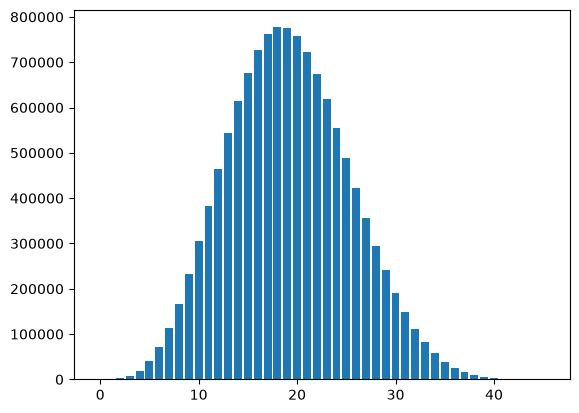

In [14]:
import matplotlib.pyplot as plt

distances = list(range(46))
sizes = [len(furthest_ranks[dist]) for dist in distances]

plt.bar(distances, sizes)
plt.show()

In [15]:
max(furthest_ranks)

45.0

In [16]:
dist = 5.0

furthest_ranks[dist]

[([6, 1, 4, 5, 7, 10, 9, 2, 8, 3], [6, 1, 4, 7, 10, 5, 9, 3, 8, 2]),
 ([1, 10, 7, 4, 8, 3, 9, 2, 6, 5], [7, 1, 10, 4, 3, 9, 8, 6, 2, 5]),
 ([1, 10, 7, 4, 8, 3, 9, 2, 6, 5], [10, 4, 1, 7, 8, 3, 9, 5, 2, 6]),
 ([1, 10, 7, 4, 8, 3, 9, 2, 6, 5], [10, 1, 4, 7, 9, 3, 8, 2, 6, 5]),
 ([1, 10, 7, 4, 8, 3, 9, 2, 6, 5], [1, 7, 4, 10, 2, 8, 3, 9, 6, 5]),
 ([8, 1, 3, 4, 9, 5, 6, 2, 10, 7], [8, 3, 9, 1, 4, 6, 2, 5, 10, 7]),
 ([8, 1, 3, 4, 9, 5, 6, 2, 10, 7], [8, 3, 1, 9, 5, 4, 2, 6, 7, 10]),
 ([8, 1, 3, 4, 9, 5, 6, 2, 10, 7], [8, 3, 1, 4, 9, 5, 10, 7, 6, 2]),
 ([8, 1, 3, 4, 9, 5, 6, 2, 10, 7], [8, 1, 3, 4, 6, 9, 2, 10, 7, 5]),
 ([8, 1, 3, 4, 9, 5, 6, 2, 10, 7], [8, 3, 1, 4, 5, 6, 2, 9, 7, 10]),
 ([8, 1, 3, 4, 9, 5, 6, 2, 10, 7], [8, 1, 3, 6, 4, 9, 2, 10, 5, 7]),
 ([8, 1, 3, 4, 9, 5, 6, 2, 10, 7], [4, 8, 3, 1, 9, 5, 6, 10, 2, 7]),
 ([8, 1, 3, 4, 9, 5, 6, 2, 10, 7], [8, 3, 4, 1, 5, 9, 6, 7, 2, 10]),
 ([8, 1, 3, 4, 9, 5, 6, 2, 10, 7], [8, 1, 3, 4, 9, 2, 5, 7, 10, 6]),
 ([8, 1, 3, 4, 9, 5, 6, 2, 10, 7],

In [17]:
furthest_ranks[dist][0]

([6, 1, 4, 5, 7, 10, 9, 2, 8, 3], [6, 1, 4, 7, 10, 5, 9, 3, 8, 2])

In [18]:
# far_a = [ind + 1 for ind in furthest_ranks[dist][0]]
# far_b = [ind + 1 for ind in furthest_ranks[dist][1]]
# #far_b = list(reversed(far_a))

far_a = furthest_ranks[dist][0][0]
far_b = furthest_ranks[dist][0][1]

# far_a

In [19]:
far_b

[6, 1, 4, 7, 10, 5, 9, 3, 8, 2]

In [20]:
algo_beta = 1.0
human_beta = 1.0
p_penalty = 0.321
algo_k = 2
universe = [0] + sushi_inds

utility_arr = np.zeros(11)
utility_arr[far_a[0]] = 1
utility_arr

human = TopKMallows(center=far_a, k=10, beta=human_beta, p=p_penalty)

algo_1 = TopKMallows(center=far_b, k=algo_k, beta=algo_beta, p=p_penalty)

human.collab_utility(algo_1, universe, utility_arr)

Set: frozenset({1, 2}) prob: 0.024968195118609086
Set: frozenset({1, 3}) prob: 0.024968195118609086
Set: frozenset({1, 4}) prob: 0.024968195118609086
Set: frozenset({1, 5}) prob: 0.024968195118609086
Set: frozenset({1, 6}) prob: 0.18449139442044896
Set: frozenset({1, 7}) prob: 0.024968195118609086
Set: frozenset({8, 1}) prob: 0.024968195118609086
Set: frozenset({1, 9}) prob: 0.024968195118609086
Set: frozenset({1, 10}) prob: 0.024968195118609086
Set: frozenset({2, 3}) prob: 0.0025999398567142485
Set: frozenset({2, 4}) prob: 0.0025999398567142485
Set: frozenset({2, 5}) prob: 0.0025999398567142485
Set: frozenset({2, 6}) prob: 0.06787059108033491
Set: frozenset({2, 7}) prob: 0.0025999398567142485
Set: frozenset({8, 2}) prob: 0.0025999398567142485
Set: frozenset({9, 2}) prob: 0.0025999398567142485
Set: frozenset({2, 10}) prob: 0.0025999398567142485
Set: frozenset({3, 4}) prob: 0.0025999398567142485
Set: frozenset({3, 5}) prob: 0.0025999398567142485
Set: frozenset({3, 6}) prob: 0.0678705910

np.float64(0.6566236699609798)

In [21]:
algo_alpha = 0.75
algo_sigma = 1.5
algo_2 = DiverseTopKMallows(center=far_b, k=algo_k, beta=algo_beta, p=p_penalty, embeddings=sushi_arr, alpha=algo_alpha, sigma=algo_sigma)

human.collab_utility(algo_2, universe, utility_arr)

Set: frozenset({1, 2}) prob: 0.02620775308874931
Set: frozenset({1, 3}) prob: 0.02608062543355255
Set: frozenset({1, 4}) prob: 0.02607324395038376
Set: frozenset({1, 5}) prob: 0.02642753513049851
Set: frozenset({1, 6}) prob: 0.1548887006903063
Set: frozenset({1, 7}) prob: 0.0261676784517067
Set: frozenset({8, 1}) prob: 0.02604995389163829
Set: frozenset({1, 9}) prob: 0.026453736118553322
Set: frozenset({1, 10}) prob: 0.02558820022280641
Set: frozenset({2, 3}) prob: 0.002810536516569536
Set: frozenset({2, 4}) prob: 0.0028109891510771936
Set: frozenset({2, 5}) prob: 0.0028105709684287995
Set: frozenset({2, 6}) prob: 0.0708063723011675
Set: frozenset({2, 7}) prob: 0.0028097487991744687
Set: frozenset({8, 2}) prob: 0.002810821712875339
Set: frozenset({9, 2}) prob: 0.002811467256830403
Set: frozenset({2, 10}) prob: 0.0028087745991890044
Set: frozenset({3, 4}) prob: 0.0028105886457031387
Set: frozenset({3, 5}) prob: 0.0028123543302564138
Set: frozenset({3, 6}) prob: 0.07101913197467732
Set: 

np.float64(0.6492361819166473)